# **感情音声の認識**

このノートブックでは，日本の感情音声を収めたコーパス（データの集合）として公式配布されている **JNV: Japanese Nonverbal Vocalization corpus** を使って，音声処理の基礎と感情音声を分類する基本的な方法を学ぶ．

ノートブックで扱う内容

- 音声波形，スペクトログラム，メルスペクトログラム，MFCC（Mel-Frequency Cepstral Coefficients; メル周波数ケプストラム係数） の定義と可視化
- ピッチ，基本周波数 F0，フォルマントの定義とPraatを使った可視化
- MFCC特徴量の PCA / LDA による可視化
- MFCCの時系列をLSTMに入力して感情分類

使用するデータセット

- 公式ページ: https://sites.google.com/site/shinnosuketakamichi/research-topics/jnv_corpus
- 公式 zip: https://ss-takashi.sakura.ne.jp/corpus/jnv/jnv_corpus_ver3.zip
- ライセンス: CC BY-SA 4.0
- 感情ラベル: angry（怒り）， disgust（嫌悪）， fear（恐怖）， happy（喜び）， sad（悲しみ）， surprise（驚き）
- 話者: F1， F2， M1， M2

JNVは通常の文章読み上げではなく，日本語の非言語発声，たとえば笑い，泣き，叫びに近い発声を含む感情音声コーパスである．
言語ではなく「声の高さ，強さ，揺れ方から感情が伝わる」状況を扱う．


In [ ]:
# プログラム一式のセットアップ
# 今回はコードとノートブックを分けてあるので，詳しい実装を確認したい人はPythonのプログラムを読むこと．
!pip -q install librosa soundfile scikit-learn pandas matplotlib seaborn japanize-matplotlib ipywidgets praat-parselmouth torch

from pathlib import Path
import sys

REPO_URL = "https://github.com/akio-kobayashi/EmotionRecog.git"  # 必要なら自分のGitHub URLに変更する
REPO_DIR = Path("/content/EmotionRecog")

if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}

sys.path.insert(0, str(REPO_DIR))
from ser import *

DATA_ROOT = Path("/content/data")
EVAL_MODE = "random"  # 発展: "speaker_holdout" にすると未知話者評価になる


## **JNV のダウンロードと展開**

**コーパス**とは，研究や学習に使うことを目的として，一定の基準で集められたデータの集合である．
音声認識や感情音声の認識では，音声ファイルと，それに対応するラベル（話した内容や感情の種別）を組にしたコーパスを利用する．

まず，JNVの公式zipファイルをColabノートブックを動かしている仮想マシン上にダウンロードし，wavファイルを展開する．


In [ ]:
wav_paths, jnv_dir = download_jnv(DATA_ROOT)
print(f"wav files: {len(wav_paths)}")
print(wav_paths[:5])


## **manifest の生成**

**manifest**（マニフェスト）とは，データセット（コーパス）に含まれる各ファイルについて，ファイルパス（ファイルのありか），ラベル，話者などの情報を表にしたものである．
機械学習では，音声ファイルを直接眺めるだけでなく，「このファイルはどの感情か」「誰の発声か」を表形式で管理する必要がある．

JNVのwavファイル名は `M1_happy_01_F.wav` のような形式である．
ファイル名から，話者ID，感情ラベル，発話番号，セッション種別を取り出す．
たとえば `M1_happy_01_F.wav` は，話者 `M1` による `happy` の発声であることを表している．
また，`R` は regular session，`F` は phrase-free session である．

In [ ]:
df = build_manifest(wav_paths, DATA_ROOT / "jnv_manifest.csv")

display(df.head())
display(pd.crosstab(df["label"], df["speaker_id"]))
display(pd.crosstab(df["label"], df["session"]))

## **音声波形・スペクトログラム・MFCC**

音声は，空気の圧力変化（粗密）が時間に沿って並んだ信号である．
コンピュータでは，この連続的な変化を一定の時間間隔で電圧として測った数列として扱う．
ここでは，1つの音声を題材にして，音声処理でよく使う表現を見ていく．

**音声波形**とは，横軸を時間，縦軸を振幅として，音の変化をそのまま描いたものである．
振幅は空気の振動の大きさに対応する．
手をたたいた音なら短い時間に大きな振幅が現れ，長く伸ばした声なら振幅が一定時間続く．

**スペクトログラム**とは，音声を短い時間区間に分け，それぞれの区間にどの周波数（音の高さ）成分がどれくらい含まれるかを色で表した図である．
横軸は時間，縦軸は周波数，色は強さを表す．
楽譜が「いつ，どの高さの音が鳴るか」を表すのに似ているが，スペクトログラムはより詳細な周波数成分まで表示できる．
このとき，各短時間区間の周波数成分を求めるために **FFT**（Fast Fourier Transform; 高速フーリエ変換）が使われる．
FFTは，時間方向に並んだ波形を，低い音から高い音までの周波数成分の強さに変換する方法である．
スペクトログラムを得るには，音声全体に一度だけFFTをかけるのではなく，短い時間窓を少しずつずらしながらFFTを繰り返し，時間軸に沿って変換結果を並べていく．
このように切り出した短い時間区間を**フレーム**と呼ぶ．
隣り合うフレームは少し重ねて取ることが多く，1つのフレームごとにスペクトログラムやMFCCの値が計算される．
そのため，MFCCの図では横方向が時間フレームの並びを表し，後半のLSTMではこのフレームの並びを時系列として入力する．

**メルスペクトログラム**とは，周波数軸を人間の聴覚特性に近いメル尺度で表したスペクトログラムである．
人間の聴覚の特性として，低い周波数の違いには比較的敏感な一方，高い周波数の細かい違いには鈍感である．
メル尺度は，この聞こえ方の違いを反映した周波数尺度である．

**MFCC**（Mel-Frequency Cepstral Coefficients）とは，メルスペクトログラムを対数変換し，DCT（Discrete Cosine Transform; 離散コサイン変換）によって少数の係数にまとめた特徴量である．
直観的には，声の音色や声道の形に関係する「なめらかなスペクトルの形」を，コンピュータで扱いやすい数値列（ベクトル）として取り出したものである．


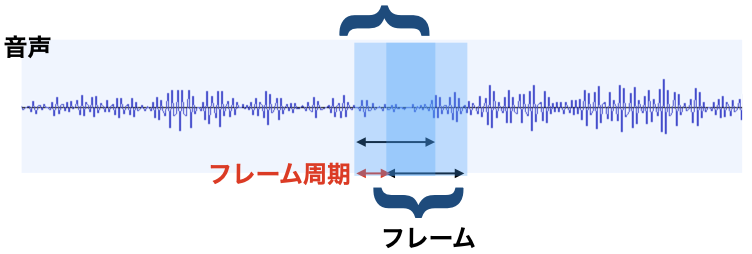

この図では，青い帯がそれぞれ1つのフレームを表す．フレームを少しずつずらして取り出すことで，音声の時間変化を追いながら，各時刻の周波数成分やMFCCを計算する．


### **音の聴き比べ**

同じ数十Hzの差でも，低い周波数どうしと高い周波数どうしでは，聴こえ方の差が同じとは限らない．
ここではメル尺度の曲線を表示し，低音側と高音側で同じHz差の2音を聴き比べる．
図では横軸がHz，縦軸がmelであり，周波数が高くなるほど曲線の傾きが小さくなることに注目する．
表では低音側と高音側でHz差は同じでも，mel差が同じではないことを確認する．


In [ ]:
interactive_mel_scale_demo()

### **人工的な信号をFFTで分析する**

実際の感情音声を分析する前に，単純な人工信号を用いてFFTで分析してみる．
2つの正弦波を足し合わせた信号は，波形だけを見ると少し複雑に見える．
しかし，FFTを使って分析すると，どの周波数成分が含まれているかがピークとして観察可能である．
この図は，「時間波形を周波数成分に分解する」という考え方の導入である．


In [ ]:
plot_fft_sine_demo()


### **短時間FFTとスペクトログラム**

次に，時間とともに周波数が変わる人工信号をFFTで分析する．
音声全体に1回だけFFTをかけると，含まれる周波数は分かるが，それがいつ現れたのかは分からない．
そこで，波形を短い区間に分割（時間窓という）して，この窓を少しずつずらしながらFFTを繰り返す．
この処理が短時間FFTであり，その結果を時間と周波数の図として表示したものがスペクトログラムとなる．
図では横軸が時間，縦軸が周波数，色がその時刻・周波数における成分の強さを表す．

In [ ]:
plot_stft_spectrogram_demo()

### **実際の音声を波形・スペクトログラムで見る**

ここからは，人工信号ではなくJNVの実際の音声を使う．
再生ボタンで音を聴き，波形では音量の時間変化，スペクトログラムでは周波数成分の時間変化，メルスペクトログラムでは人間の聴覚に近い周波数軸での強さを確認する．


In [ ]:
demo_label = "happy" #@param ["angry", "disgust", "fear", "happy", "sad", "surprise"]
demo_row, y_demo, sr_demo = load_demo_audio(df, label=demo_label)
demo_path = demo_row["path"]

print(demo_row.to_dict())
print(f"samples: {len(y_demo)}, sampling rate: {sr_demo} Hz, duration: {len(y_demo) / sr_demo:.2f} s")

display(Audio(y_demo, rate=sr_demo))
plot_waveform(y_demo, sr_demo)
plot_spectrogram(y_demo, sr_demo)
mel_db = plot_mel_spectrogram(y_demo, sr_demo)

### **音響特徴量を観察する**

JVNの感情，話者，区分，発話番号を変えながら，音声再生，波形，スペクトログラム，メルスペクトログラム，MFCCを確認する．
必要に応じて F0 やフォルマントも表示できる．
波形では発話の始まり・終わりと強さ，スペクトログラムでは濃い帯として現れる周波数成分，MFCCでは係数ごとの時間変化に注目する．


In [ ]:
show_sample_explorer(df, default_label="happy")

### **2つの音声を並べて比較する**

2つのサンプルを選び，音声再生，波形，スペクトログラム，MFCCを左右で比較する．
感情差だけでなく，話者差や区分差も観察できる．
左右の図では，同じ種類の図を横に見比べて，音量，周波数成分，MFCCの時間変化がどこで似ていて，どこで違うかを観察する．


In [ ]:
compare_samples(df, default_left="happy", default_right="sad")


音の強さは，物理的には非常に広い範囲の値を取る．
そのため，MFCCではメルスペクトログラムのパワーを**対数変換**する．
対数変換により，パワーの大きな差を圧縮して扱いやすくする．
身近な例では，地震のマグニチュードも同様である．

**以下の音源フィルタモデルは読み飛ばしてもよい**

音声生成の基本的な考え方として，**音源フィルタモデル**（source-filter model）がある．
これは，人間の音声を，声帯振動などによる**声帯音源**と，口腔・咽頭・鼻腔などからなる**声道フィルタ**の組み合わせとして考えるモデルである．
時間波形で見ると，音源信号が声道フィルタを通って音声になる，すなわち畳み込みとして表される（信号処理）．
周波数領域で見ると，畳み込みは掛け算に対応するため，おおまかには次のように考えられる．

`音声スペクトル ≒ 声帯音源スペクトル × 声道フィルタの周波数特性`

ここで両辺の対数を取ると，右辺の掛け算は足し算に変わる．

`log(音声スペクトル) ≒ log(声帯音源スペクトル) + log(声道フィルタの周波数特性)`

この性質により，声帯音源に由来する細かな倍音の構造と，声道フィルタに由来するなめらかなスペクトル包絡を，数学的に扱いやすくなる．
ただし，実際には対数メルスペクトルをDCTで要約した特徴量を扱うため，対数変換では声帯音源と声道フィルタが完全に分離されるわけではない．

**ここまで読み飛ばせる**

対数変換したメルスペクトル（**対数メルスペクトル**）に **DCT**を適用する．
DCTは，並んだ数値を「ゆっくり変化する成分」と「細かく変化する成分」に分ける変換である．
FFT（Fast Fourier Transform; 高速フーリエ変換） が時間波形を周波数成分に分解するのと似ているが，MFCCでは周波数方向に並んだ対数メルスペクトルを分解する．

ここで重要なのが，**スペクトル包絡**と，F0や倍音に関わる細かな構造の違いである．
スペクトル包絡とは，スペクトル全体をなめらかに結んだ**大まかな形**（概形）である．
これは口の開き方，舌の位置，唇の丸めなど，声道形状や調音（言語音を作る動き）の違いを反映する．
たとえば「あ」と「い」では，口や舌の形が違うため，スペクトル包絡も変わる．

一方，声帯振動に由来する基本周波数 F0 や倍音の構造は，スペクトル上の細かな山や谷として現れる．
ただし，MFCCはメルフィルタバンク，対数変換，DCTによってスペクトルを圧縮した特徴量であり，F0や倍音を直接測定できる特徴量ではない．
そのため，声の高さそのものを調べたい場合は，F0の推定を別に用いる．

MFCCの低次の係数は主にスペクトル包絡を表す傾向にあり，高次の係数にはより細かなスペクトル形状の変化が含まれやすい．
音声認識では，声道形状や音色に関係する情報を比較的少数の係数にまとめるためにMFCCがよく使われる．
ただし感情音声では，声の高さ，抑揚，強さ，話速も重要なので，MFCCだけでこれらのすべてを説明できるわけではない．

このノートブックでは，直観的な説明としてスペクトル包絡を「全体的な形」，F0や倍音に関わる細かな山や谷を「細かな構造」と呼ぶ．
なお，MFCCはこの2つを完全に分離するのではなく，対数メルスペクトルをDCTを用いて要約した特徴量であることに注意する．

MFCCをそのままヒートマップで可視化すると，係数ごとの値の範囲がそろっていないため，色の違いが見えにくくなることがある．
特にC0（最初の係数）は，対数メルスペクトルにDCTをかけたときの直流成分に相当し，スペクトル全体の平均的な大きさを表す．
そのため音声のエネルギーに近い情報を含むが，厳密には時間波形のエネルギーそのものではない．
C0は値の範囲が大きくなりやすいため，ヒートマップの色のスケールを支配しやすい係数である．
このノートブックのMFCC図では， C0を除いてC1以降を係数ごとに標準化して表示する．
したがって，値そのものではなくて「各係数がその発話の中でいつ大きくなり，いつ小さくなるか」を見るための図であることに注意する．
また，下段には低次の係数の時間変化を折れ線として表示する．

In [ ]:
plot_log_mel_dct_frame(mel_db)
plot_dct_reconstruction_demo(mel_db)
mfcc_demo = plot_mfcc(y_demo, sr_demo)


後でPCAやLDAによって特徴量を2次元平面上で可視化するために，MFCCの各係数について平均と標準偏差を計算する．
これは，時間とともに変化するMFCCを，1つの発話につき固定長のベクトルへ要約する操作となる．

この要約では「いつ声が高くなったか」「どこで急に音声が強くなったか」といった時間方向の情報が失われることに注意する．
そのため，このノートブックの後半で実践する感情の分類モデルでは，MFCCの時系列そのものをLSTMに入力する．
平均と標準偏差は，まず特徴量の全体像を掴むための入門的な表現として位置づける．


In [ ]:
mfcc_summary = display_mfcc_summary(mfcc_demo)

## **ピッチ・基本周波数**

**ピッチ**とは，人間が感じる音の高さである．
音響学では，周期的な音声の高さに対応する物理量として**基本周波数 F0**を用いる．
F0 は，声帯振動が1秒間に何回繰り返されるかを表す周波数で，単位は Hz である．

F0が200 Hzなら，声帯は1秒間に約200回振動していることを意味する．
一般的に，F0 が高いほど高い声として聞こえ，F0 が低いほど低い声として聞こえる．

感情音声の認識では，ピッチは重要な手がかりとなる．
驚きや怒りでは声が高くなったり急に変化することがあり，悲しみでは低く平坦になりやすいケースがある．
個人差はあるが，「楽しそうな声は高さがよく上下し，元気のない声は単調に聞こえる」という日常的な感覚と対応している．

In [ ]:
pitch_stats = draw_waveform_with_pitch(demo_path)
display(pd.DataFrame([pitch_stats]).round(2))

pitch_stats_df = summarize_pitch_by_label(df)

## **Praat によるスペクトログラム・フォルマントの描画**

**フォルマント**とは，声道で共鳴して強く現れる周波数帯のことである．
音声学では，第1フォルマント F1，第2フォルマント F2，第3フォルマント F3 などとして表す．
フォルマントは，**母音の違いや口の形を表す重要な手がかり**である．

たとえば，同じ高さの声でも「あ」と「い」が違う音として聞こえるのは，声帯だけでなく，口や舌の形によって共鳴のしかたが変わるためである．
この共鳴の違いがフォルマントとして観察される．

ここでは `praat-parselmouth`モジュール を使って，Praat（分析アプリケーション）で推定したフォルマント軌跡をスペクトログラム上に重ねて表示する．
JNVは非言語発声を含むため，母音のように常に安定したフォルマントが現れるとは限らない．
したがって，ここでは厳密な音声学的分析というよりも，感情ラベルごとの音響的な違いを観察する教材として使う．
図では背景の濃淡がスペクトログラム，色付きの点が推定された F1，F2，F3 の周波数である．
点がなめらかにつながっている区間ほど，フォルマント推定が比較的安定していると考えやすい．

**注意:** セルを実行して表示された図の F1，F2，F3 は Praat が各時刻で推定した値である．処理の都合上，無音区間，無声区間，雑音的な区間でも点が表示されることがある．点が描かれているからといって，その時刻に母音のような安定した声道共鳴が実際に存在するとは限らない．背景のスペクトログラムでエネルギーが強い**有声らしい区間**と重なっているかを確認すること．


In [ ]:
target_label = "happy" #@param ["angry", "disgust", "fear", "happy", "sad", "surprise"]
sample_row = df[df["label"] == target_label].iloc[0]
print(sample_row.to_dict())
draw_spectrogram_with_formants(sample_row["path"])

formant_stats = summarize_formants_by_label(df)

## **MFCCと特徴量**

**特徴量**とは，機械学習で使うモデルに対して入力することを目的として，データから取り出して（加工・前処理した）数値である．
最初に可視化したように，音声そのものは長い波形であるが，そのままでは機械学習では扱いにくいため，MFCCのような特徴量に変換する．

ここでは，コーパスのwavファイルを 16 kHz のモノラル音声(1チャンネル)として読み込み，MFCC，ΔMFCC，ΔΔMFCC を計算する．
ΔMFCCはMFCCの時間変化，ΔΔMFCCはその変化のさらに変化を表す．
車の動きにたとえると，MFCCが位置，ΔMFCCが速度，ΔΔMFCCが加速度に近い役割を持つ．

さらに，PCA/LDAによる可視化のために，各係数の平均と標準偏差を結合して固定長のベクトルを作る．
なお，感情音声の分類モデルであるLSTMでは，平均化していないMFCCの時系列を使う．

In [ ]:
X, y, groups, label_encoder = build_mfcc_stat_dataset(df)
print("X:", X.shape)
print("labels:", list(label_encoder.classes_))

## **MFCCのPCA/LDAによる可視化**

ここでは，MFCCから作った固定長の特徴量を2次元平面上に可視化して，感情や話者による差がどのように見えるかを確認する．
MFCCのような高次元のデータを2次元平面上で可視化すると，本来の完全な情報は失われてしまうが，人間が全体の傾向をつかみやすくなる．

**主成分分析 PCA**（Principal Component Analysis）とは，多数の特徴量を，データのばらつきが大きい少数の軸に変換する方法である．
第1主成分 PC1 はデータが最も大きく広がる方向，第2主成分 PC2 は PC1 と直交し，次に大きく広がる方向である．

直観的には，机の上に散らばった点を，最も横長に見える方向から写真に撮るようなものである．
PCAでは，感情ラベルを使わずに，データ全体の分散が大きくなる方向を第1主成分，第2主成分として選ぶ．
ただし，データのばらつきの方向で見える違いが，必ずしも感情の違いを表すとは限らない．
話者による差，録音条件，音量差などの方が大きければ，それらが主成分として現れることがある．

また，PCAの散布図に外れ値があると，軸の表示範囲が外れ値に引っ張られてしまい，ほとんどの点が細い帯のようにつぶれて見えることがある．
そのような図では，PC2の方向には情報がないように誤解しやすくなる．

そこで，このノートブックのPCAの可視化では，PCAの計算自体は全サンプルで行った上で，描画する際に中心部分のサンプルだけを表示し，PC2方向を少し拡大して見せている．
これは「PCAを都合よく変えた」のではなく，外れ値が原因で図が読みにくくなることを避けるための表示上の工夫である．
また，図のタイトルには，表示しているサンプル数を「中心部分を表示」として示している．
散布図では1点が1つの音声サンプルを表し，色は感情ラベル，記号は話者を表す．
同じ色の点がまとまっていれば感情差が見えている可能性があり，同じ記号の点がまとまっていれば話者差が強く見えている可能性がある．

可視化された図から，PCAでは感情のデータがきれいに分かれないことがみて取れるはずである．
この場合，PCAの散布図では感情差よりも，話者差や録音条件などの違いが強く見えている可能性がある．


In [ ]:
X_scaled, pca_df, pca = plot_pca_mfcc(df, X)

PCAを使って感情があまりきれいに分離しなかったとしても，結果にはそれなりの価値がある．
PCAはいわゆる**教師なし**の分析方法なので，感情ラベルを知らずに軸を決める．
つまり，PCA は「感情を認識するための最適な軸」を探しているわけではない．

次に **LDA**（Linear Discriminant Analysis; 線形判別分析）を使って分析する．
LDAはラベルを使う**教師あり**の方法である．
LDAでは，感情ラベルを使って，感情を表す各クラスの平均どうしを引き離し，同じ感情クラス内のばらつきが小さく見えるような方向を探す．

直観的には，PCAが「点群全体がよく広がって見える向き」を探すのに対して，LDA は「感情ラベルごとに分けて見やすい向き」を探す．
したがって，PCAよりも感情ごとに分かれて可視化されやすいが，これは感情ラベルの情報を使って軸を作成しているためである．
未知のデータに対する分類性能を示すものではなく，あくまで特徴量を調べるための可視化である．

In [ ]:
lda_df, lda = plot_lda_mfcc(df, X_scaled, y, label_encoder)
plot_pca_by_speaker(pca_df)


## **MFCCの時系列を使うLSTM**

ここからは，MFCCを平均や標準偏差に要約することをせず，時間方向に並んだ系列として扱う．
音声は時間とともに変化するデータなので，感情を考えるときには，ある瞬間の音色だけでなく，声の立ち上がり，揺れ，持続，終わり方も重要になる．

**LSTM**（Long Short-Term Memory） とは，特に時間方向に並んだデータ（系列データ）を扱うための再帰型ニューラルネットワークの一種である．
現在の入力だけでなく，それ以前の入力から受け継いだ内部状態を使って予測を行う．
普通のニューラルネットワークが1枚の写真を見るモデルだとすれば，LSTMは動画のフレームを順番に見て内容を判断するモデルに近い．

このノートブックでは，LSTMの実装に **PyTorch** を使う．
PyTorchは，ニューラルネットワークを設計し，データを使って学習・評価するためのライブラリ（フレームワーク）である．
なお，ノートブックではPyTorchの詳細には立ち入らず，感情音声を分類する上で必要な，音響特徴量の前処理や結果の評価方法について学ぶことにする．

**以下はPyTorchの概要である．読み飛ばしてもよい**
PyTorchでは，データは主に **テンソル** と呼ばれる多次元配列として扱われる．この実験では，1つの音声を `時間フレーム × 特徴量` の表として表し，複数の音声をまとめて `発話数 × 時間フレーム × 特徴量` の形にする．LSTMはこの時間フレームの並びを順に読み，最後に感情ラベルを予測する．

まず「MFCC 時系列から感情ラベルを学習できるか」を確認するための基本設定として，`random` split を既定値にする．
`speaker_holdout` は未知話者に対する評価で，4話者しかないJNVでは非常に厳しく，感情の予測がきちんとできないことがある．
その場合は，モデルが感情を学習したとは言えない．

また，各時刻の入力としてMFCC，ΔMFCC，ΔΔMFCCを使う．
これにより，音色そのものだけでなく，音色がどのように時間変化しているかといった情報もモデルに渡す．
発話ごとに長さが違うため，短い系列にはpadding（パディング; ゼロ詰め）を入れるが，`pack_padded_sequence` を使ってpadding部分を系列の有効な時刻として扱わないようにする．


In [ ]:
train_idx, test_idx = make_split(df, y, groups, mode=EVAL_MODE)
display_split_summary(df, y, groups, label_encoder, train_idx, test_idx, EVAL_MODE)

**以下はニューラルネットワークの学習についてである．読み飛ばしてもよい**

ニューラルネットワークの学習では，いくつかのデータをまとめて処理する（ミニバッチ化）．
しかし，音声のように長さの異なるデータを扱う場合は，データそのままでは長さが違うので同じミニバッチにまとめられない．
そこで，まとめた系列についてはその長さを一番長いものとして，長さの足りない短い系列の末尾には0を追加して長さをそろえる．
この操作を **padding** と呼ぶ．

しかし，paddingは本物の音声ではないので，データに対するさまざまな操作（たとえば平均と分散のような標準化）は，paddingを含まない実際の音声フレームだけから推定する．
また，標準化のパラメータは学習データだけで計算し，テストデータの情報が学習手順に混ざらないようにする．
これは，試験問題を事前に見てから勉強方法を決めない，という考え方に似ている．

In [ ]:
X_seq, seq_lengths, n_features, inner_train_idx, val_idx, frame_scaler = build_sequence_dataset(
    df,
    train_idx,
    y,
)

**以下はLSTMについての説明である．読み飛ばしてもよい**

LSTMには，padding済みの系列と，（paddingする前の）本来のフレーム長を一緒に渡す．
`pack_padded_sequence` は，系列の本当の長さを使ってpadding部分を無視するための仕組みである．

このノートブックでは感情を分類するモデルとして，**双方向 LSTM** を使う．
通常のLSTMは発話の前から後ろへ順にデータを読んでいくが，双方向LSTMは後ろから前へ読む流れも同時に使う．
さらに，LSTMが各時刻で出力した値を発話全体にわたって平均（pooling）する．

前述の通り，感情は最後の音響特徴だけで決まるとは限らない．
たとえば，最初に急に高くなった声，途中で震える声，最後まで強く続く声など，発話全体に分散した手がかりがある．
そこでpadding部分を除いた平均（mean pooling）あるいは最大（max pooling） を使って，発話全体の情報をまとめる．

In [ ]:
lstm_model, history_df, device = train_lstm(
    X_seq,
    seq_lengths,
    y,
    inner_train_idx,
    val_idx,
    label_encoder,
)

In [ ]:
lstm_pred, lstm_result, prediction_summary, cm_lstm = evaluate_lstm(
    lstm_model,
    X_seq,
    seq_lengths,
    y,
    train_idx,
    test_idx,
    label_encoder,
    device,
)

## **実行後の結果の見方**

セルを実行すると，多数派ベースライン，LSTM の accuracy / macro F1，予測ラベル分布，classification report，混同行列が表示される．
ここでは，数値を1つだけ見て判断せず，複数の出力を合わせて分析することが重要である．

まず，評価指標の意味を確認する．
ここでは，ある1つのラベルを正解として見たときの数を使って定義する．
TP（True Positive; 真陽性）はそのラベルを正しくそのラベルだと予測した数，FP（False Positive; 偽陽性）は別のラベルをそのラベルだと誤って予測した数，FN（False Negative; 偽陰性）はそのラベルを別のラベルだと誤って予測した数である．

**accuracy**（正解率）は，全テストデータのうち，予測が正解した割合である．
たとえば100個中60個を正しく分類できれば accuracy は0.60である．
ただし，accuracyだけを見ると危険な場合がある．
ある感情のサンプル数が他に比べて多い場合，その感情ばかりを正解として予測するだけでもaccuracyが高くなることがある．

**precision**（適合率）は，あるラベルだと予測したデータのうち，実際にそのラベルだった割合である．

$$
\mathrm{precision} = \frac{TP}{TP + FP}
$$

たとえば `happy` と10個予測して，そのうち6個が本当に `happy` なら，`happy` のprecisionは0.60である．
これは「そのラベルだと言ったときに，どれくらい信用できるか」を表す．

**recall**（再現率）は，実際にそのラベルであるデータのうち，モデルがそのラベルとして見つけられた割合である．

$$
\mathrm{recall} = \frac{TP}{TP + FN}
$$

たとえば本当の `happy` が15個あり，そのうち6個を `happy` と予測できたなら，`happy` のrecallは0.40である．
これは「そのラベルのデータをどれくらい取りこぼさず見つけられたか」を表す．

**F1-score**は，precisionとrecallのバランスを表す指標である．
precisionだけ高くてもrecallが低い場合，またはrecallだけ高くてもprecisionが低い場合，よい分類器とは言いにくい．
F1-scoreはこの2つの値の調和平均であり，両方が高いときに高くなる．

$$
F1 = \frac{2 \cdot \mathrm{precision} \cdot \mathrm{recall}}{\mathrm{precision} + \mathrm{recall}}
$$

**macro F1**は，各ラベルのF1-scoreを単純平均した値である．
`angry`，`disgust`，`fear`，`happy`，`sad`，`surprise` を同じ重みで平均するため，特定のラベルだけをよく当てるモデルには厳しい指標である．
感情分類のように，各感情を同じように扱いたい場合は，accuracyだけでなくmacro F1を見ることが重要である．
macro F1は各感情のF1-scoreを同じ重みで平均するため，少数の感情を無視していないかを確認しやすい．

classification report の **support** は，そのラベルに属するテストデータの数である．
supportが少ないラベルでは，1個の誤分類でprecisionやrecallが大きく変わるので，結果を分析するときに注意が必要である．

次に **Majority Baseline（多数派ベースライン）** を確認する．
これは，データセットの中で最も多く出現するラベルを，すべての入力に対して常に予測する最も単純な基準である．

たとえばテストデータで `surprise` が最も多い場合，音声の中身を見ずにすべて `surprise` と予測する．
この基準とLSTMのaccuracyやmacro F1がほとんど変わらない場合，モデルは感情を十分に学習できていない可能性がある．

次に **予測ラベル分布**を確認する．
`predicted_count` が1つ，または2つの感情に極端に集中している場合，モデルは多くの入力を同じ感情として扱っていることを意味する．
たとえば，ほとんどを `surprise` と予測している場合，混同行列の `surprise` 列だけ色が濃くなる．
この場合，accuracy が少し高くても，感情の違いを学習したとはいえない．

最後に **混同行列**を確認する．
縦軸が正解ラベル，横軸が予測ラベルである．
対角線上の値は正解数を表す．
対角線上のマスの色が濃いほど，その感情を正しく分類できている．
対角線以外のマスに大きな値がある場合は，どの感情をどの感情と間違えたかを表す．

確認するときのヒント

- accuracy が高くても，predicted_count が1つのラベルに偏っていないか確認する．
- macro F1 が低い場合，一部の感情だけを当てて，他の感情をほとんど分類できていない可能性がある．
- precision が低い感情は，その感情だと予測しても外れやすい．
- recall が低い感情は，本当はその感情であるデータを取りこぼしやすい．
- support が少ない感情では，precisionやrecallの値が不安定になりやすい．
- 対角線に値がある: その感情をある程度識別できている．
- 1つの列だけ色が濃い: モデルが同じラベルばかり予測しており，学習が失敗している可能性が高い．
- `angry` と `happy`，`sad` と `angry` などが混ざる: MFCC時系列だけでは声の強さや抑揚の似た感情を分けにくい可能性がある．
- `surprise` が比較的当たりやすい: 声の立ち上がりや高さの変化など，音響的に目立つ特徴が識別できている可能性がある．
- `disgust` や `fear` が弱い: 感情の音響的な境界が曖昧，またはデータ数・話者数が不足している可能性がある．

このノートブックは，高性能な感情を分類するモデルを作成することが目的ではない．
LSTMを使った分類モデルは，MFCCを時系列として（時間方向の変化を残したまま）分類器に入力すると，どのような結果になるかを調べる基本モデルである．
実行後は，混同行列が1つの列に潰れていないか，多数派ベースラインを上回っているか，どの感情ペアで誤分類が多いかを確認すること．